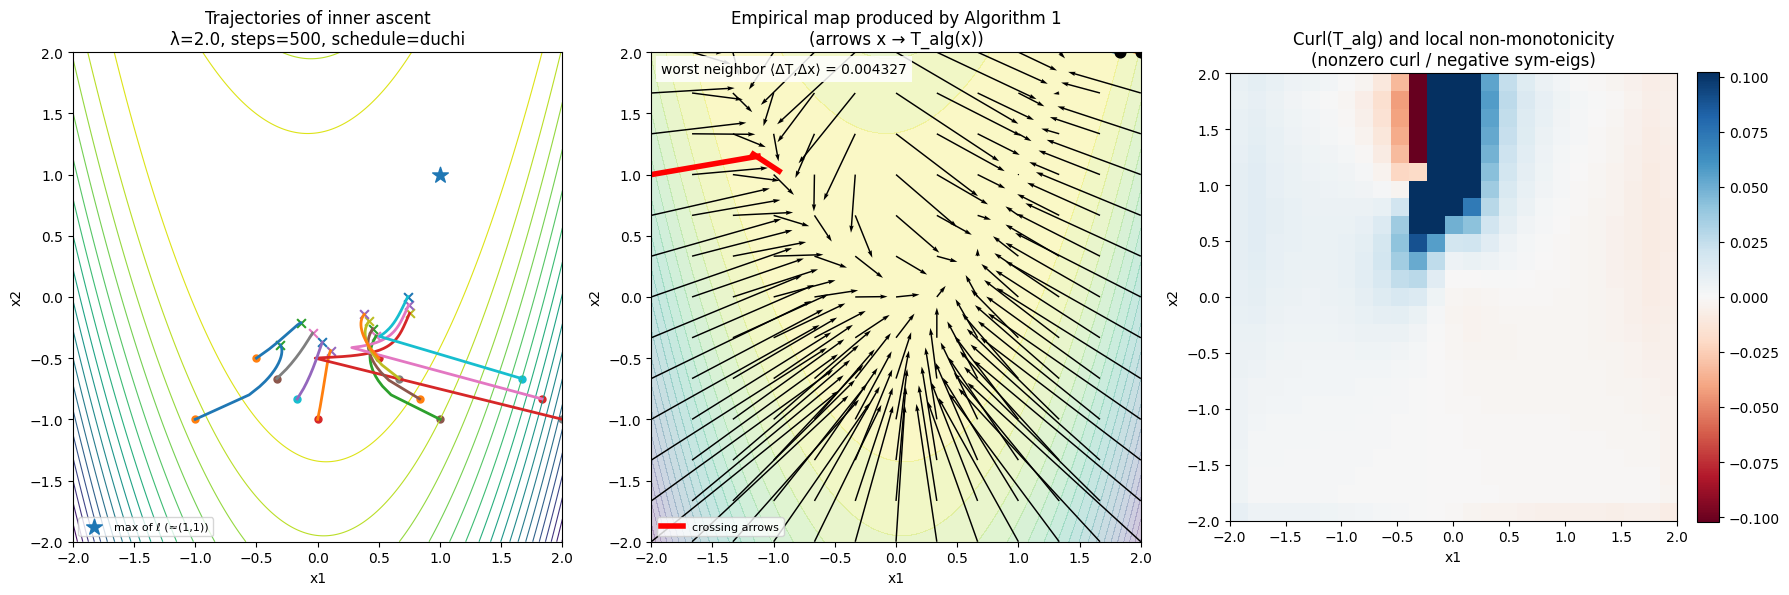

Key numbers:
  worst neighbor monotonicity score: 0.00432668  (negative => NOT monotone)
  mean |curl|: 0.0250597
  min eig_min(sym(J_T)): 0.0734202  (negative => violates PSD requirement)


In [2]:
"""
Rosenbrock 2D counterexample for Algorithm 1 (inner particle ascent).

We consider, for each anchor point x0 in a grid, the inner objective:
    f_{x0}(z) = ell(z) - lam * ||z - x0||^2
with ell(z) = -alpha * Rosenbrock(z)  (inverted Rosenbrock).

Algorithm 1 inner update (Duchi-style option):
    z_{s+1} = z_s + eta_s * ( grad_ell(z_s) - 2*lam*(z_s - x0) ),
    eta_s = eta0 / sqrt(s)   (or constant).

We compute the empirical map T_alg(x0) = z_S and visualize:
- trajectories of inner ascent,
- arrow field x0 -> T_alg(x0),
- a detected "crossing arrows" pair (segment intersection),
- curl(T_alg), and regions where sym(J_T) has negative eigenvalue.

Dependencies: numpy, matplotlib
"""

import math
import numpy as np
import matplotlib.pyplot as plt


# =========================
# Inverted Rosenbrock loss
# =========================

def ell_rosenbrock(z, a=1.0, b=5.0, alpha=0.5):
    """
    ell(x,y) = -alpha * ((a-x)^2 + b*(y-x^2)^2)
    Maximum is at (x,y)=(a,a^2) = (1,1) for the default a=1.
    """
    x = z[..., 0]
    y = z[..., 1]
    return -alpha * ((a - x) ** 2 + b * (y - x ** 2) ** 2)


def grad_ell_rosenbrock(z, a=1.0, b=5.0, alpha=0.5):
    """
    Gradient of ell_rosenbrock.
    R(x,y) = (a-x)^2 + b*(y-x^2)^2
    dR/dx = 2(x-a) - 4*b*x*(y-x^2)
    dR/dy = 2*b*(y-x^2)
    ell = -alpha*R => grad ell = -alpha * grad R
    """
    x = z[..., 0]
    y = z[..., 1]
    dR_dx = 2.0 * (x - a) - 4.0 * b * x * (y - x ** 2)
    dR_dy = 2.0 * b * (y - x ** 2)
    dL_dx = -alpha * dR_dx
    dL_dy = -alpha * dR_dy
    return np.stack([dL_dx, dL_dy], axis=-1)


# =========================
# Algorithm 1 inner ascent
# =========================

def particle_ascent_map(X0, lam, steps, eta0, schedule="duchi", track_indices=()):
    """
    Vectorized inner ascent for many anchors X0.

    X0: (N,2) array of anchors; initialization is z0 = X0.
    Returns:
        T: (N,2) final points after 'steps'
        traj: dict idx -> (steps+1,2) trajectory for tracked indices
    """
    X0 = np.asarray(X0, dtype=float)
    Z = X0.copy()

    track_indices = list(track_indices)
    traj = {idx: [Z[idx].copy()] for idx in track_indices}

    for s in range(1, steps + 1):
        if schedule == "duchi":
            eta = eta0 / math.sqrt(s)
        elif schedule == "constant":
            eta = eta0
        else:
            raise ValueError("schedule must be 'duchi' or 'constant'")

        G = grad_ell_rosenbrock(Z) - 2.0 * lam * (Z - X0)
        Z = Z + eta * G

        for idx in track_indices:
            traj[idx].append(Z[idx].copy())

    traj = {idx: np.array(path) for idx, path in traj.items()}
    return Z, traj


# =========================
# Geometry diagnostics
# =========================

def compute_curl_and_sym_eigmin(T_grid, xs, ys):
    """
    Given T_grid shape (ny,nx,2) and coordinate vectors xs, ys (uniform),
    compute:
      curl(T) = dT2/dx - dT1/dy
      eig_min of sym(J_T) = min eigenvalue of (J + J^T)/2 at each grid point.
    """
    Tx = T_grid[:, :, 0]
    Ty = T_grid[:, :, 1]

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]

    # np.gradient returns derivatives along axis0 (y) then axis1 (x)
    dTx_dy, dTx_dx = np.gradient(Tx, dy, dx)
    dTy_dy, dTy_dx = np.gradient(Ty, dy, dx)

    curl = dTy_dx - dTx_dy

    # Symmetric part S = (J+J^T)/2 for J=[[dTx_dx, dTx_dy],[dTy_dx, dTy_dy]]
    a = dTx_dx
    d = dTy_dy
    b = 0.5 * (dTx_dy + dTy_dx)
    # eigenvalues of [[a,b],[b,d]]
    eig_min = 0.5 * ((a + d) - np.sqrt((a - d) ** 2 + 4.0 * b ** 2))

    return curl, eig_min


def find_worst_neighbor_monotonicity_pair(X_grid, T_grid):
    """
    Scan horizontal/vertical neighbors and return the most negative
    monotonicity score <T(u)-T(v), u-v> and the corresponding pair.
    """
    ny, nx, _ = X_grid.shape
    best_score = float("inf")
    best_pair = None

    # horizontal neighbors
    for j in range(ny):
        for i in range(nx - 1):
            u = X_grid[j, i]
            v = X_grid[j, i + 1]
            Tu = T_grid[j, i]
            Tv = T_grid[j, i + 1]
            score = float(np.dot(Tu - Tv, u - v))
            if score < best_score:
                best_score = score
                best_pair = ((j, i), (j, i + 1))

    # vertical neighbors
    for j in range(ny - 1):
        for i in range(nx):
            u = X_grid[j, i]
            v = X_grid[j + 1, i]
            Tu = T_grid[j, i]
            Tv = T_grid[j + 1, i]
            score = float(np.dot(Tu - Tv, u - v))
            if score < best_score:
                best_score = score
                best_pair = ((j, i), (j + 1, i))

    return best_score, best_pair


def _orient(a, b, c):
    """2D orientation (cross product) of (b-a) and (c-a)."""
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def segments_intersect(p1, q1, p2, q2, eps=1e-12):
    """
    Proper segment intersection test (excludes collinear overlap handling).
    """
    o1 = _orient(p1, q1, p2)
    o2 = _orient(p1, q1, q2)
    o3 = _orient(p2, q2, p1)
    o4 = _orient(p2, q2, q1)
    return (o1 * o2 < -eps) and (o3 * o4 < -eps)


def angle_deg(u, v):
    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    c = float(np.dot(u, v) / (nu * nv))
    c = float(np.clip(c, -1.0, 1.0))
    return float(math.degrees(math.acos(c)))


def find_crossing_arrows(X, T, max_points=200, min_angle=20.0, seed=0):
    """
    Try to find an actual pair of intersecting arrows (segments) x->T(x).

    To keep it fast, we subsample at most 'max_points' arrows.
    Returns indices (i,j) into the subsampled arrays, or None if not found.
    """
    rng = np.random.default_rng(seed)
    N = X.shape[0]
    if N > max_points:
        idx = rng.choice(N, size=max_points, replace=False)
        Xs = X[idx]
        Ts = T[idx]
    else:
        idx = np.arange(N)
        Xs = X
        Ts = T

    M = Xs.shape[0]
    best = None
    best_ang = 0.0

    for i in range(M):
        p1 = Xs[i]
        q1 = Ts[i]
        d1 = q1 - p1
        for j in range(i + 1, M):
            p2 = Xs[j]
            q2 = Ts[j]
            if segments_intersect(p1, q1, p2, q2):
                ang = angle_deg(d1, q2 - p2)
                if ang >= min_angle and ang > best_ang:
                    best_ang = ang
                    best = (i, j)

    if best is None:
        return None, (idx, Xs, Ts)
    return best, (idx, Xs, Ts)


# =========================
# Plotting / main
# =========================

def main():
    # ----- User-facing knobs -----
    BOUNDS = (-2.0, 2.0)
    GRID_RES = 25

    LAM = 2.0      # smaller => more movement => stronger violations
    STEPS = 500
    ETA0 = 0.02         # base stepsize
    SCHEDULE = "duchi"  # "duchi" (eta0/sqrt(s)) or "constant"

    QUIVER_STRIDE = 2   # arrow subsampling for readability

    # Grid of anchors x0
    xs = np.linspace(BOUNDS[0], BOUNDS[1], GRID_RES)
    ys = np.linspace(BOUNDS[0], BOUNDS[1], GRID_RES)
    XX, YY = np.meshgrid(xs, ys)
    X_grid = np.stack([XX, YY], axis=-1)           # (ny,nx,2)
    X0 = X_grid.reshape(-1, 2)                     # (N,2)

    # Choose a few trajectories to plot (central region)
    track = []
    for j in range(GRID_RES):
        for i in range(GRID_RES):
            x, y = XX[j, i], YY[j, i]
            if (-1.0 <= x <= 2.0) and (-1.0 <= y <= 2.0) and ((i + j) % 6 == 0):
                track.append(j * GRID_RES + i)
    track = track[:12]

    # Run Algorithm 1 inner ascent (vectorized)
    T_flat, traj = particle_ascent_map(X0, lam=LAM, steps=STEPS, eta0=ETA0,
                                       schedule=SCHEDULE, track_indices=track)
    T_grid = T_flat.reshape(GRID_RES, GRID_RES, 2)

    # Diagnostics
    curl, eig_min = compute_curl_and_sym_eigmin(T_grid, xs, ys)
    worst_score, worst_pair = find_worst_neighbor_monotonicity_pair(X_grid, T_grid)

    # Find a “crossing arrows” example (segment intersection)
    crossing_pair, (sub_idx, Xs, Ts) = find_crossing_arrows(X0, T_flat, max_points=220, min_angle=25.0, seed=0)

    # Background loss contours
    gx = np.linspace(BOUNDS[0], BOUNDS[1], 240)
    gy = np.linspace(BOUNDS[0], BOUNDS[1], 240)
    GX, GY = np.meshgrid(gx, gy)
    L = ell_rosenbrock(np.stack([GX, GY], axis=-1))

    # ----- Plot -----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))

    # (1) Trajectories on loss contours
    ax = axes[0]
    ax.contour(GX, GY, L, levels=22, linewidths=0.8)
    ax.scatter([1.0], [1.0], marker="*", s=140, label="max of ℓ (≈(1,1))")
    for idx, path in traj.items():
        ax.plot(path[:, 0], path[:, 1], linewidth=2.0)
        ax.scatter([path[0, 0]], [path[0, 1]], s=25)          # start
        ax.scatter([path[-1, 0]], [path[-1, 1]], s=40, marker="x")  # end
    ax.set_title(f"Trajectories of inner ascent\nλ={LAM}, steps={STEPS}, schedule={SCHEDULE}")
    ax.set_xlim(BOUNDS); ax.set_ylim(BOUNDS)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower left", fontsize=8)

    # (2) Arrow field + highlighted crossing arrows + worst monotonicity neighbor
    ax = axes[1]
    ax.contourf(GX, GY, L, levels=22, alpha=0.25)
    U = T_grid[:, :, 0] - XX
    V = T_grid[:, :, 1] - YY
    ax.quiver(XX[::QUIVER_STRIDE, ::QUIVER_STRIDE],
              YY[::QUIVER_STRIDE, ::QUIVER_STRIDE],
              U[::QUIVER_STRIDE, ::QUIVER_STRIDE],
              V[::QUIVER_STRIDE, ::QUIVER_STRIDE],
              angles="xy", scale_units="xy", scale=1.0, width=0.003)

    # highlight worst neighbor monotonicity violation
    (j1, i1), (j2, i2) = worst_pair
    p1, p2 = X_grid[j1, i1], X_grid[j2, i2]
    q1, q2 = T_grid[j1, i1], T_grid[j2, i2]
    ax.plot([p1[0], q1[0]], [p1[1], q1[1]], linewidth=4)
    ax.plot([p2[0], q2[0]], [p2[1], q2[1]], linewidth=4)
    ax.scatter([p1[0], p2[0]], [p1[1], p2[1]], c="k", s=60, zorder=5)
    ax.scatter([q1[0], q2[0]], [q1[1], q2[1]], c="r", s=60, zorder=5)
    ax.text(0.02, 0.98, f"worst neighbor ⟨ΔT,Δx⟩ = {worst_score:.4g}",
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    # highlight a genuine “crossing arrows” pair if found
    if crossing_pair is not None:
        i, j = crossing_pair
        c1, d1 = Xs[i], Ts[i]
        c2, d2 = Xs[j], Ts[j]
        ax.plot([c1[0], d1[0]], [c1[1], d1[1]], color="red", linewidth=4, label="crossing arrows")
        ax.plot([c2[0], d2[0]], [c2[1], d2[1]], color="red", linewidth=4)
        ax.legend(loc="lower left", fontsize=8)

    ax.set_title("Empirical map produced by Algorithm 1\n(arrows x → T_alg(x))")
    ax.set_xlim(BOUNDS); ax.set_ylim(BOUNDS)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")

    # (3) Curl + mark where sym(J) has negative eigenvalue
    ax = axes[2]
    # robust color range
    vmax = np.percentile(np.abs(curl), 95)
    im = ax.imshow(curl, origin="lower",
                   extent=[BOUNDS[0], BOUNDS[1], BOUNDS[0], BOUNDS[1]],
                   cmap="RdBu", vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    mask = eig_min < 0.0
    if np.any(mask):
        yy_idx, xx_idx = np.where(mask)
        ax.scatter(xs[xx_idx], ys[yy_idx], s=6, c="k", alpha=0.35, label="eig_min(sym(J_T)) < 0")
        ax.legend(loc="lower left", fontsize=8)

    ax.set_title("Curl(T_alg) and local non-monotonicity\n(nonzero curl / negative sym-eigs)")
    ax.set_xlim(BOUNDS); ax.set_ylim(BOUNDS)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

    print("Key numbers:")
    print(f"  worst neighbor monotonicity score: {worst_score:.6g}  (negative => NOT monotone)")
    print(f"  mean |curl|: {np.mean(np.abs(curl)):.6g}")
    print(f"  min eig_min(sym(J_T)): {np.min(eig_min):.6g}  (negative => violates PSD requirement)")


if __name__ == "__main__":
    main()
